# The Prediction of Online VS In-Store Shopping

**Understading the dataset**


In [15]:
# import libraries
# Core
import numpy as np
import pandas as pd


In [16]:
# load datasets
df = pd.read_csv('shopping.csv')
df.head()

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level,gender,city_tier,shopping_preference
0,56,221111,6.5,12,0.7,1,6,16,16,28551,...,7,7,1,3,6,5,2,Other,Tier 3,Store
1,69,96029,8.2,13,2.7,6,9,14,1,124056,...,3,4,9,6,8,1,7,Male,Tier 3,Hybrid
2,46,19055,6.4,4,2.1,10,8,2,0,81939,...,4,10,1,1,3,3,3,Female,Tier 3,Store
3,32,53170,6.4,11,0.7,2,10,20,3,35901,...,10,2,4,8,2,6,6,Female,Tier 1,Store
4,60,244016,6.0,5,0.7,2,5,18,16,131971,...,2,5,8,9,7,1,6,Male,Tier 3,Store


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11789 entries, 0 to 11788
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          11789 non-null  int64  
 1   monthly_income               11789 non-null  int64  
 2   daily_internet_hours         11789 non-null  float64
 3   smartphone_usage_years       11789 non-null  int64  
 4   social_media_hours           11789 non-null  float64
 5   online_payment_trust_score   11789 non-null  int64  
 6   tech_savvy_score             11789 non-null  int64  
 7   monthly_online_orders        11789 non-null  int64  
 8   monthly_store_visits         11789 non-null  int64  
 9   avg_online_spend             11789 non-null  int64  
 10  avg_store_spend              11789 non-null  int64  
 11  discount_sensitivity         11789 non-null  int64  
 12  return_frequency             11789 non-null  int64  
 13  avg_delivery_day

In [18]:
# understanding data
df['shopping_preference'].value_counts() # the dataset is imbalanced

,count
shopping_preference,
Store,10244
Online,1176
Hybrid,369


# Data visualization

In [19]:
# import libraries
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
fig = plt.figure(figsize=(18,6))

<Figure size 1800x600 with 0 Axes>

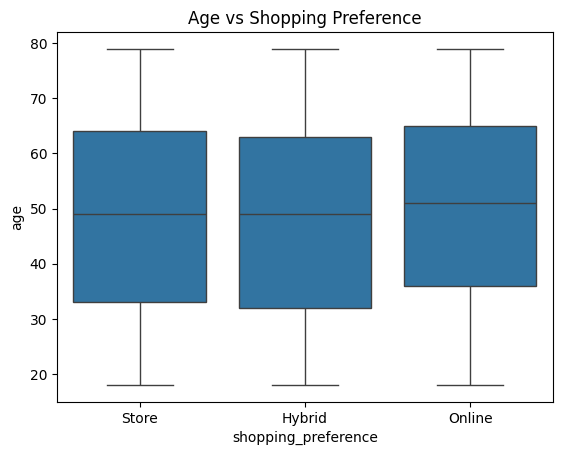

In [23]:
# boxplot of age by shopping preference
sns.boxplot(data=df, x="shopping_preference", y="age")
plt.title("Age vs Shopping Preference")
plt.show()

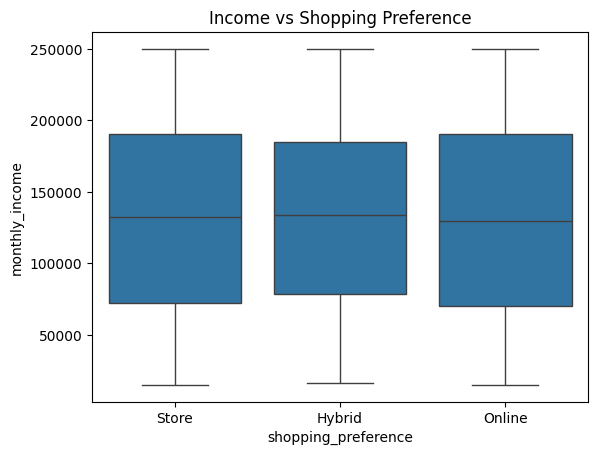

In [24]:
# boxplot of monthly income by shopping preference
sns.boxplot(data=df, x="shopping_preference", y="monthly_income")
plt.title("Income vs Shopping Preference")
plt.show()

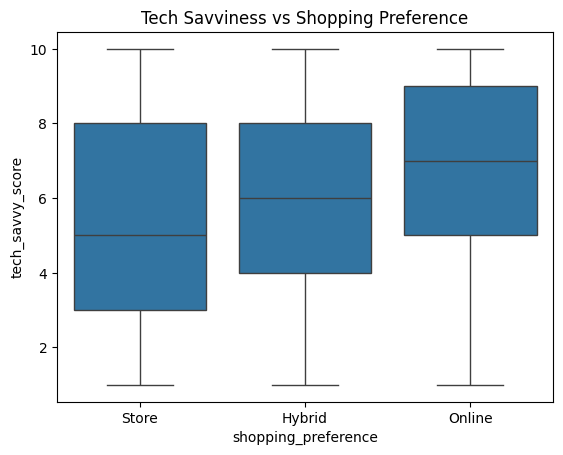

In [27]:
# boxplot of tech savviness by shopping preference
sns.boxplot(data=df, x="shopping_preference", y="tech_savvy_score")
plt.title("Tech Savviness vs Shopping Preference")
plt.show()

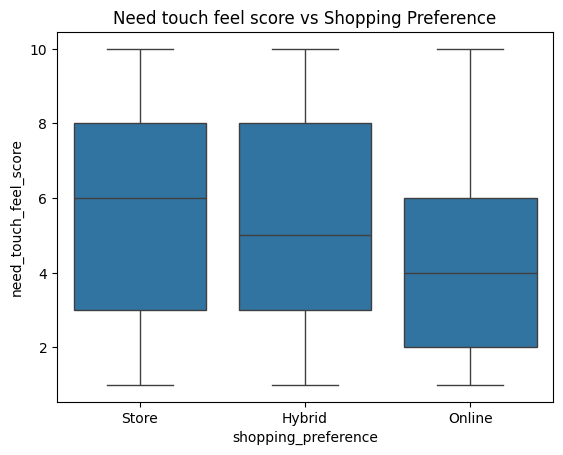

In [28]:
# boxplot of need in touch feel by shopping preference
sns.boxplot(data=df, x="shopping_preference", y="need_touch_feel_score")
plt.title("Need touch feel score vs Shopping Preference")
plt.show()

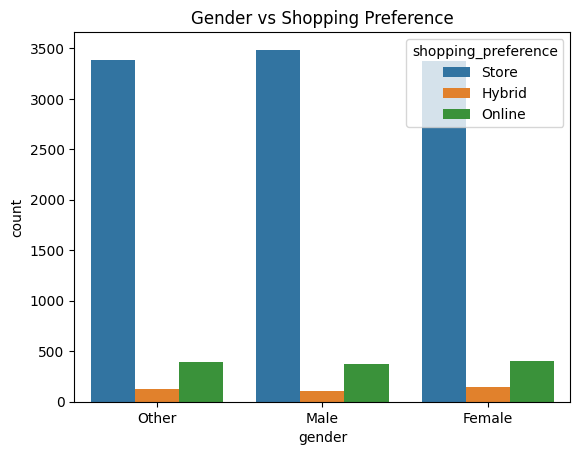

In [29]:
# how is gender distributed by shopping preference
sns.countplot(data=df, x="gender", hue="shopping_preference")
plt.title("Gender vs Shopping Preference")
plt.show()

# Handle categorical values

In [31]:
# copy our dataset to df1
df1=df.copy()
df1=pd.get_dummies(df, columns=['gender', 'city_tier'],drop_first = True)
df1.head()

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level,shopping_preference,gender_Male,gender_Other,city_tier_Tier 2,city_tier_Tier 3
0,56,221111,6.5,12,0.7,1,6,16,16,28551,...,1,3,6,5,2,Store,False,True,False,True
1,69,96029,8.2,13,2.7,6,9,14,1,124056,...,9,6,8,1,7,Hybrid,True,False,False,True
2,46,19055,6.4,4,2.1,10,8,2,0,81939,...,1,1,3,3,3,Store,False,False,False,True
3,32,53170,6.4,11,0.7,2,10,20,3,35901,...,4,8,2,6,6,Store,False,False,False,False
4,60,244016,6.0,5,0.7,2,5,18,16,131971,...,8,9,7,1,6,Store,True,False,False,True


In [32]:
# divide dataset into label and features
X = df1.drop("shopping_preference", axis=1)
Y = df1["shopping_preference"]

In [34]:
X.head()

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level,gender_Male,gender_Other,city_tier_Tier 2,city_tier_Tier 3
0,56,221111,6.5,12,0.7,1,6,16,16,28551,...,7,1,3,6,5,2,False,True,False,True
1,69,96029,8.2,13,2.7,6,9,14,1,124056,...,4,9,6,8,1,7,True,False,False,True
2,46,19055,6.4,4,2.1,10,8,2,0,81939,...,10,1,1,3,3,3,False,False,False,True
3,32,53170,6.4,11,0.7,2,10,20,3,35901,...,2,4,8,2,6,6,False,False,False,False
4,60,244016,6.0,5,0.7,2,5,18,16,131971,...,5,8,9,7,1,6,True,False,False,True


In [33]:
Y.head()

,shopping_preference
0,Store
1,Hybrid
2,Store
3,Store
4,Store


# Train Test Split

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=42)